# Importing relevant libraries

In [2]:
import pandas as pd
import numpy as np

from datetime import datetime

import matplotlib.pyplot as plt
import seaborn as sns
sns.set()

#Machine learning
from sklearn.preprocessing import LabelEncoder

# Importing the Car price prediciton dataset v3 and making a copy

In [4]:
df_init = pd.read_csv("Car details v3.csv")
df = df_init.copy()

In [5]:
df.head()

,name,year,selling_price,km_driven,fuel,seller_type,transmission,owner,mileage,engine,max_power,torque,seats
0,Maruti Swift Dzire VDI,2014,450000,145500,Diesel,Individual,Manual,First Owner,23.4 kmpl,1248 CC,74 bhp,190Nm@ 2000rpm,5.0
1,Skoda Rapid 1.5 TDI Ambition,2014,370000,120000,Diesel,Individual,Manual,Second Owner,21.14 kmpl,1498 CC,103.52 bhp,250Nm@ 1500-2500rpm,5.0
2,Honda City 2017-2020 EXi,2006,158000,140000,Petrol,Individual,Manual,Third Owner,17.7 kmpl,1497 CC,78 bhp,"12.7@ 2,700(kgm@ rpm)",5.0
3,Hyundai i20 Sportz Diesel,2010,225000,127000,Diesel,Individual,Manual,First Owner,23.0 kmpl,1396 CC,90 bhp,22.4 kgm at 1750-2750rpm,5.0
4,Maruti Swift VXI BSIII,2007,130000,120000,Petrol,Individual,Manual,First Owner,16.1 kmpl,1298 CC,88.2 bhp,"11.5@ 4,500(kgm@ rpm)",5.0


In [6]:
df.shape
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8128 entries, 0 to 8127
Data columns (total 13 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   name           8128 non-null   object 
 1   year           8128 non-null   int64  
 2   selling_price  8128 non-null   int64  
 3   km_driven      8128 non-null   int64  
 4   fuel           8128 non-null   object 
 5   seller_type    8128 non-null   object 
 6   transmission   8128 non-null   object 
 7   owner          8128 non-null   object 
 8   mileage        7907 non-null   object 
 9   engine         7907 non-null   object 
 10  max_power      7913 non-null   object 
 11  torque         7906 non-null   object 
 12  seats          7907 non-null   float64
dtypes: float64(1), int64(3), object(9)
memory usage: 825.6+ KB


Key Insights
- We have 13 attributes with selling_price as our target.
- There are clear signs of missing values given the less Non-Null count under seats, torque, etc
- The data types to many numeric attributes like engine, mileage, max_power, and torque are not integers or floats but rather objects due to units being included.

# Checking for duplicates and dropping them. (Data Cleaning)

In [9]:
df.duplicated().sum()

1202

In [10]:
(1202/8128)*100

14.788385826771652

- 1202 are exact duplicates accounting for 14.79% of the entire dataset. This is a significant number.
- They will be dropped to avoid model bias and potential data leakage.

In [12]:
df_no_duplicates = df.drop_duplicates().reset_index(drop=True)

In [13]:
df_no_duplicates.shape

(6926, 13)

## Changing text values into floating point values 

### Checking the fuel column

In [16]:
df_no_duplicates["fuel"].unique()

array(['Diesel', 'Petrol', 'LPG', 'CNG'], dtype=object)

### Checking seller type

In [18]:
df_no_duplicates["seller_type"].unique()

array(['Individual', 'Dealer', 'Trustmark Dealer'], dtype=object)

### Checking transmission type

In [20]:
df_no_duplicates["transmission"].unique()

array(['Manual', 'Automatic'], dtype=object)

### Checking owner 

In [22]:
df_no_duplicates["owner"].unique()

array(['First Owner', 'Second Owner', 'Third Owner',
       'Fourth & Above Owner', 'Test Drive Car'], dtype=object)

### Checking Mileage 

In [24]:
# Extracting them into different columns for easy working using regex's
df_no_duplicates[["mileage_value", "mileage_unit"]] = df_no_duplicates["mileage"].str.extract(r'([\d.]+)\s*([a-zA-Z/]+)')

In [25]:
df_no_duplicates["mileage_value"] = pd.to_numeric(df_no_duplicates["mileage_value"], errors='coerce')

In [26]:
df_no_duplicates["mileage_unit"].unique()

array(['kmpl', 'km/kg', nan], dtype=object)

### Checking engine

In [28]:
df_no_duplicates[["engine_volume", "engine_v_units"]]=df_no_duplicates["engine"].str.extract(r'([\d.]+)\s*([a-zA-Z]+)')

In [29]:
df_no_duplicates["engine_volume"] = pd.to_numeric(df_no_duplicates["engine_volume"], errors='coerce')

In [30]:
df_no_duplicates["engine_v_units"].unique()

array(['CC', nan], dtype=object)

### Checking max_power 

In [32]:
df_no_duplicates[["max_power_value", "max_power_units"]]=df_no_duplicates["max_power"].str.extract(r'([\d.]+)\s*([a-zA-Z]+)')

In [33]:
df_no_duplicates["max_power_value"] = pd.to_numeric(df_no_duplicates["max_power_value"], errors='coerce')

In [34]:
df_no_duplicates["max_power_units"].unique()

array(['bhp', nan], dtype=object)

### Checking torque

In [36]:
df_no_duplicates["torque"].head()

0              190Nm@ 2000rpm
1         250Nm@ 1500-2500rpm
2       12.7@ 2,700(kgm@ rpm)
3    22.4 kgm at 1750-2750rpm
4       11.5@ 4,500(kgm@ rpm)
Name: torque, dtype: object

In [37]:
torque_clean = df_no_duplicates['torque'].str.replace(',', '')

torque_val = pd.to_numeric(
    torque_clean.str.extract(r'^([\d.]+)')[0], 
    errors='coerce'
)

In [38]:
is_kgm = torque_clean.str.contains('kgm', case=False, na=False)

df_no_duplicates['torque_nm'] = np.where(is_kgm, torque_val * 9.80665, torque_val)

df_no_duplicates[['torque', 'torque_nm']].head()

,torque,torque_nm
0,190Nm@ 2000rpm,190.000000
1,250Nm@ 1500-2500rpm,250.000000
2,"12.7@ 2,700(kgm@ rpm)",124.544455
3,22.4 kgm at 1750-2750rpm,219.668960
4,"11.5@ 4,500(kgm@ rpm)",112.776475


In [39]:
df_no_duplicates.head()

,name,year,selling_price,km_driven,fuel,seller_type,transmission,owner,mileage,engine,max_power,torque,seats,mileage_value,mileage_unit,engine_volume,engine_v_units,max_power_value,max_power_units,torque_nm
0,Maruti Swift Dzire VDI,2014,450000,145500,Diesel,Individual,Manual,First Owner,23.4 kmpl,1248 CC,74 bhp,190Nm@ 2000rpm,5.0,23.40,kmpl,1248.0,CC,74.00,bhp,190.000000
1,Skoda Rapid 1.5 TDI Ambition,2014,370000,120000,Diesel,Individual,Manual,Second Owner,21.14 kmpl,1498 CC,103.52 bhp,250Nm@ 1500-2500rpm,5.0,21.14,kmpl,1498.0,CC,103.52,bhp,250.000000
2,Honda City 2017-2020 EXi,2006,158000,140000,Petrol,Individual,Manual,Third Owner,17.7 kmpl,1497 CC,78 bhp,"12.7@ 2,700(kgm@ rpm)",5.0,17.70,kmpl,1497.0,CC,78.00,bhp,124.544455
3,Hyundai i20 Sportz Diesel,2010,225000,127000,Diesel,Individual,Manual,First Owner,23.0 kmpl,1396 CC,90 bhp,22.4 kgm at 1750-2750rpm,5.0,23.00,kmpl,1396.0,CC,90.00,bhp,219.668960
4,Maruti Swift VXI BSIII,2007,130000,120000,Petrol,Individual,Manual,First Owner,16.1 kmpl,1298 CC,88.2 bhp,"11.5@ 4,500(kgm@ rpm)",5.0,16.10,kmpl,1298.0,CC,88.20,bhp,112.776475


In [40]:
df_no_duplicates.columns

Index(['name', 'year', 'selling_price', 'km_driven', 'fuel', 'seller_type',
       'transmission', 'owner', 'mileage', 'engine', 'max_power', 'torque',
       'seats', 'mileage_value', 'mileage_unit', 'engine_volume',
       'engine_v_units', 'max_power_value', 'max_power_units', 'torque_nm'],
      dtype='object')

### Calculating car age

In [42]:
current_year = datetime.now().year

In [43]:
df_no_duplicates["car_age"] = current_year - df_no_duplicates["year"]

### Generating car brand

In [45]:
df_no_duplicates["brand"] = df_no_duplicates["name"].str.split().str[0]

In [46]:
df_no_duplicates["brand"].unique()

array(['Maruti', 'Skoda', 'Honda', 'Hyundai', 'Toyota', 'Ford', 'Renault',
       'Mahindra', 'Tata', 'Chevrolet', 'Fiat', 'Datsun', 'Jeep',
       'Mercedes-Benz', 'Mitsubishi', 'Audi', 'Volkswagen', 'BMW',
       'Nissan', 'Lexus', 'Jaguar', 'Land', 'MG', 'Volvo', 'Daewoo',
       'Kia', 'Force', 'Ambassador', 'Ashok', 'Isuzu', 'Opel', 'Peugeot'],
      dtype=object)

### Making a copy for cleaning missing values

In [48]:
df_no_missing_values = df_no_duplicates.copy()

In [49]:
df_no_missing_values.head()

,name,year,selling_price,km_driven,fuel,seller_type,transmission,owner,mileage,engine,...,seats,mileage_value,mileage_unit,engine_volume,engine_v_units,max_power_value,max_power_units,torque_nm,car_age,brand
0,Maruti Swift Dzire VDI,2014,450000,145500,Diesel,Individual,Manual,First Owner,23.4 kmpl,1248 CC,...,5.0,23.40,kmpl,1248.0,CC,74.00,bhp,190.000000,12,Maruti
1,Skoda Rapid 1.5 TDI Ambition,2014,370000,120000,Diesel,Individual,Manual,Second Owner,21.14 kmpl,1498 CC,...,5.0,21.14,kmpl,1498.0,CC,103.52,bhp,250.000000,12,Skoda
2,Honda City 2017-2020 EXi,2006,158000,140000,Petrol,Individual,Manual,Third Owner,17.7 kmpl,1497 CC,...,5.0,17.70,kmpl,1497.0,CC,78.00,bhp,124.544455,20,Honda
3,Hyundai i20 Sportz Diesel,2010,225000,127000,Diesel,Individual,Manual,First Owner,23.0 kmpl,1396 CC,...,5.0,23.00,kmpl,1396.0,CC,90.00,bhp,219.668960,16,Hyundai
4,Maruti Swift VXI BSIII,2007,130000,120000,Petrol,Individual,Manual,First Owner,16.1 kmpl,1298 CC,...,5.0,16.10,kmpl,1298.0,CC,88.20,bhp,112.776475,19,Maruti


## Working on missing values 

In [51]:
df_no_missing_values.isna().sum()

name                 0
year                 0
selling_price        0
km_driven            0
fuel                 0
seller_type          0
transmission         0
owner                0
mileage            208
engine             208
max_power          205
torque             209
seats              208
mileage_value      208
mileage_unit       208
engine_volume      208
engine_v_units     208
max_power_value    209
max_power_units    209
torque_nm          209
car_age              0
brand                0
dtype: int64

In [52]:
df_no_missing_values.shape

(6926, 22)

In [53]:
df_dropped_na = df_no_missing_values.copy()
df_dropped_na = df_dropped_na.dropna()
df_dropped_na.shape

(6717, 22)

In [54]:
6926-6717

209

In [55]:
(209/6926)*100

3.017614784868611

Key insights
- The missing values are approximately 3%
- Deleting them will have a inimal effect on our model formulation. Let us try it when they are entirely dropped and when other methods are used.

# Feature Selection

In [58]:
df_dropped_na.columns

Index(['name', 'year', 'selling_price', 'km_driven', 'fuel', 'seller_type',
       'transmission', 'owner', 'mileage', 'engine', 'max_power', 'torque',
       'seats', 'mileage_value', 'mileage_unit', 'engine_volume',
       'engine_v_units', 'max_power_value', 'max_power_units', 'torque_nm',
       'car_age', 'brand'],
      dtype='object')

In [59]:
columns_to_keep = ['km_driven', 'fuel', 'seller_type',
       'transmission', 'owner', 'seats', 'mileage_value',
         'engine_volume', 'max_power_value',  'torque_nm',
       'car_age', 'brand', 'selling_price'      
                  ]

In [60]:
df_cleaned = df_dropped_na[columns_to_keep].copy()

In [61]:
df_cleaned.head()

,km_driven,fuel,seller_type,transmission,owner,seats,mileage_value,engine_volume,max_power_value,torque_nm,car_age,brand,selling_price
0,145500,Diesel,Individual,Manual,First Owner,5.0,23.40,1248.0,74.00,190.000000,12,Maruti,450000
1,120000,Diesel,Individual,Manual,Second Owner,5.0,21.14,1498.0,103.52,250.000000,12,Skoda,370000
2,140000,Petrol,Individual,Manual,Third Owner,5.0,17.70,1497.0,78.00,124.544455,20,Honda,158000
3,127000,Diesel,Individual,Manual,First Owner,5.0,23.00,1396.0,90.00,219.668960,16,Hyundai,225000
4,120000,Petrol,Individual,Manual,First Owner,5.0,16.10,1298.0,88.20,112.776475,19,Maruti,130000


# Explolatory Data Analysis (EDA)

## Histogram for Selling Price

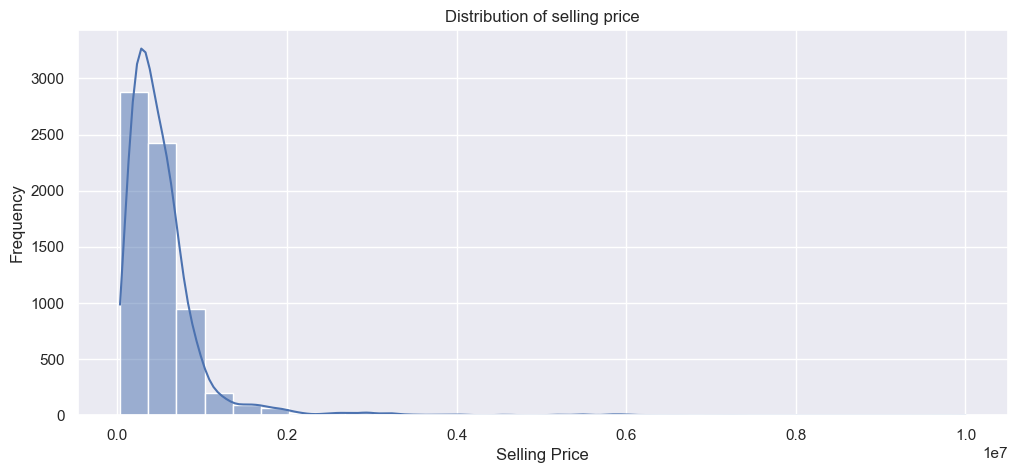

In [64]:
plt.figure(figsize=(12,5))
sns.histplot(df_cleaned["selling_price"], kde=True, bins=30)
plt.title("Distribution of selling price")
plt.xlabel("Selling Price")
plt.ylabel("Frequency")
plt.show()

## Box plot of selling price and fuel type

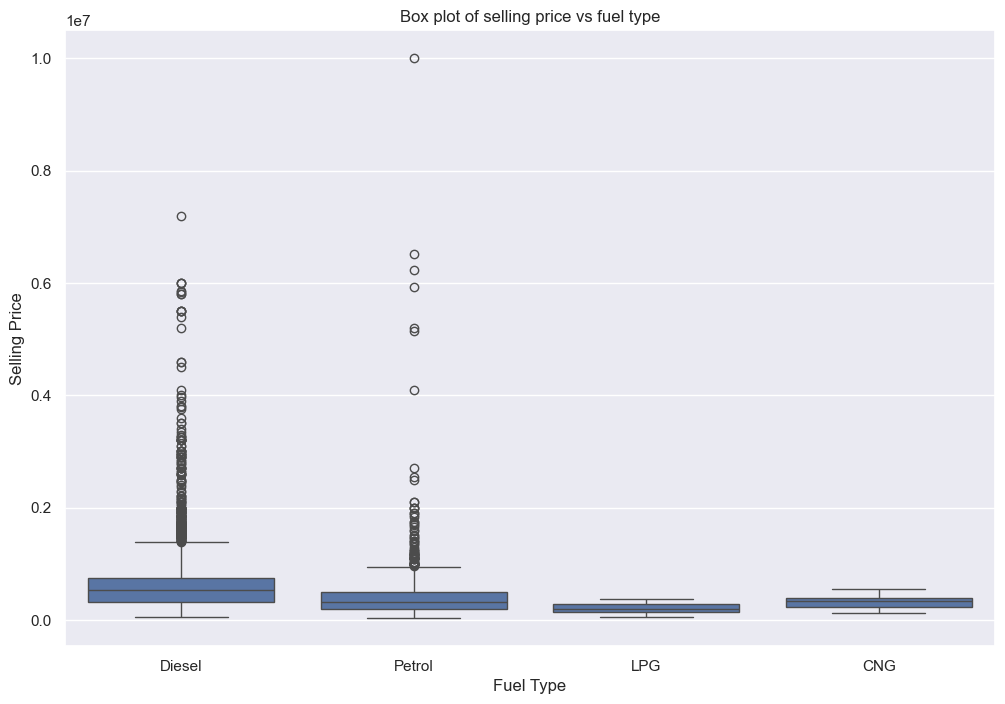

In [66]:
plt.figure(figsize=(12,8))
sns.boxplot(data=df_cleaned,x="fuel", y="selling_price")
plt.title("Box plot of selling price vs fuel type")
plt.xlabel("Fuel Type")
plt.ylabel("Selling Price")
plt.show()

## Scatter plot  of selling price and car age

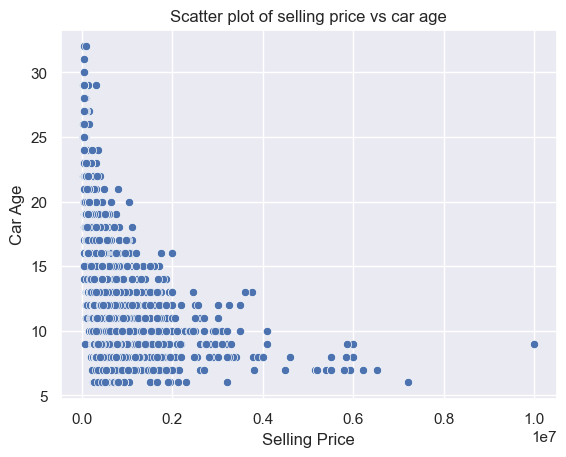

In [68]:
sns.scatterplot(data=df_cleaned, x="selling_price", y="car_age")
plt.title("Scatter plot of selling price vs car age")
plt.xlabel("Selling Price")
plt.ylabel("Car Age")
plt.show()

Key Insights
- Selling price is exponentially distributted which supposses a log transformation for the outcome.

# Data Transformation

## Data Transformation using Natural log on the outcome

In [72]:
df_cleaned["log_selling_price"]=np.log(df_cleaned["selling_price"])
df_cleaned.head()

,km_driven,fuel,seller_type,transmission,owner,seats,mileage_value,engine_volume,max_power_value,torque_nm,car_age,brand,selling_price,log_selling_price
0,145500,Diesel,Individual,Manual,First Owner,5.0,23.40,1248.0,74.00,190.000000,12,Maruti,450000,13.017003
1,120000,Diesel,Individual,Manual,Second Owner,5.0,21.14,1498.0,103.52,250.000000,12,Skoda,370000,12.821258
2,140000,Petrol,Individual,Manual,Third Owner,5.0,17.70,1497.0,78.00,124.544455,20,Honda,158000,11.970350
3,127000,Diesel,Individual,Manual,First Owner,5.0,23.00,1396.0,90.00,219.668960,16,Hyundai,225000,12.323856
4,120000,Petrol,Individual,Manual,First Owner,5.0,16.10,1298.0,88.20,112.776475,19,Maruti,130000,11.775290


## Replotting the log transformed values

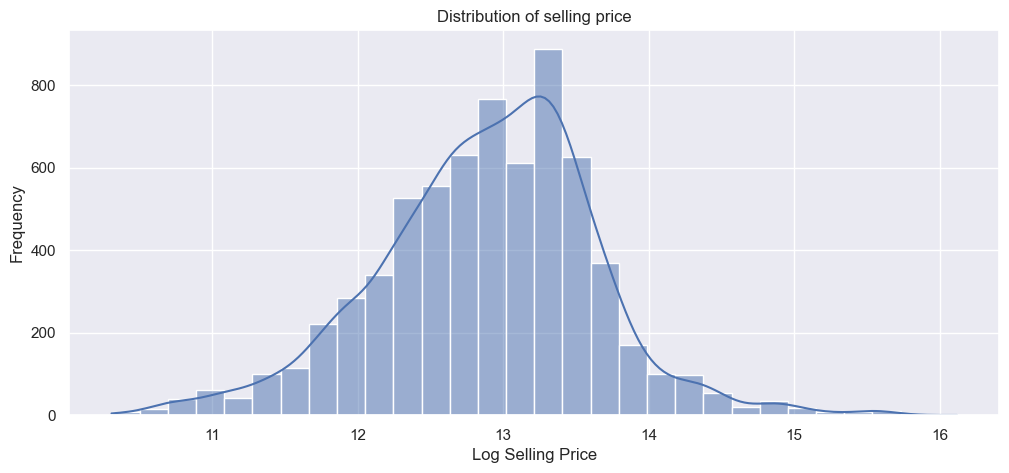

In [74]:
plt.figure(figsize=(12,5))
sns.histplot(df_cleaned["log_selling_price"], kde=True, bins=30)
plt.title("Distribution of selling price")
plt.xlabel("Log Selling Price")
plt.ylabel("Frequency")
plt.show()

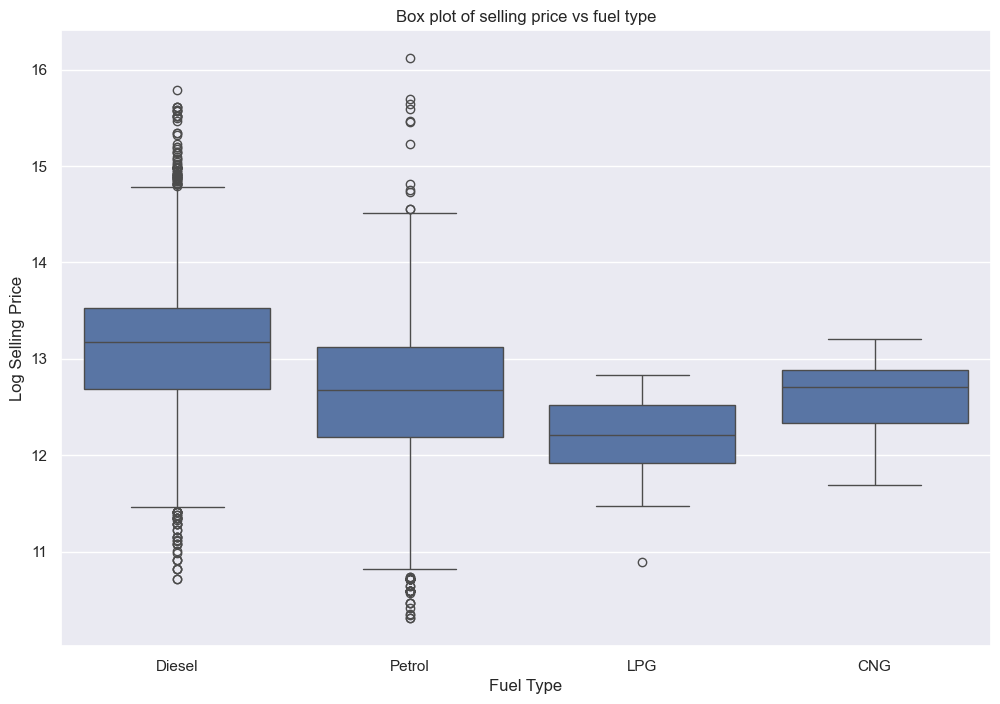

In [75]:
plt.figure(figsize=(12,8))
sns.boxplot(data=df_cleaned,x="fuel", y="log_selling_price")
plt.title("Box plot of selling price vs fuel type")
plt.xlabel("Fuel Type")
plt.ylabel("Log Selling Price")
plt.show()

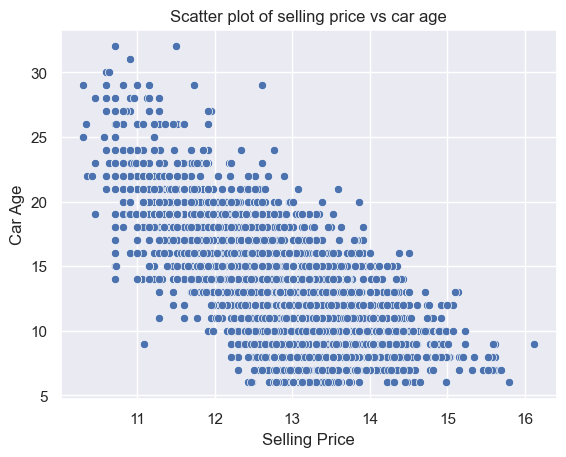

In [76]:
sns.scatterplot(data=df_cleaned, x="log_selling_price", y="car_age")
plt.title("Scatter plot of selling price vs car age")
plt.xlabel("Selling Price")
plt.ylabel("Car Age")
plt.show()

## Using Label Encoder that is ordinal in nature for the owner attribute

In [78]:
le_owner = LabelEncoder()
df_cleaned["owner"] = le_owner.fit_transform(df_cleaned["owner"])

## Using One hot encoding which is nominal in nature for the nominal features

In [80]:
df_encoded = pd.get_dummies(
    df_cleaned,
    columns=["fuel","seller_type", "transmission"],
    drop_first=True, # This removes reference group to curb multicollinearity
    dtype=int
)

## Using Label Encoding for the high dimensional brand column however much its nominal

In [82]:
le_brand = LabelEncoder()
df_encoded["brand"] = le_brand.fit_transform(df_encoded["brand"])

In [83]:
df_encoded.columns

Index(['km_driven', 'owner', 'seats', 'mileage_value', 'engine_volume',
       'max_power_value', 'torque_nm', 'car_age', 'brand', 'selling_price',
       'log_selling_price', 'fuel_Diesel', 'fuel_LPG', 'fuel_Petrol',
       'seller_type_Individual', 'seller_type_Trustmark Dealer',
       'transmission_Manual'],
      dtype='object')

In [84]:
df_transformed = df_encoded[
    ['km_driven', 'owner', 'seats', 'mileage_value', 'engine_volume',
       'max_power_value', 'torque_nm', 'car_age', 'brand',
        'fuel_Diesel', 'fuel_LPG', 'fuel_Petrol',
       'seller_type_Individual', 'seller_type_Trustmark Dealer',
       'transmission_Manual', 'log_selling_price']
].copy()

In [85]:
df_transfr.head()

,km_driven,owner,seats,mileage_value,engine_volume,max_power_value,torque_nm,car_age,brand,selling_price,log_selling_price,fuel_Diesel,fuel_LPG,fuel_Petrol,seller_type_Individual,seller_type_Trustmark Dealer,transmission_Manual
0,145500,0,5.0,23.40,1248.0,74.00,190.000000,12,20,450000,13.017003,1,0,0,1,0,1
1,120000,2,5.0,21.14,1498.0,103.52,250.000000,12,26,370000,12.821258,1,0,0,1,0,1
2,140000,4,5.0,17.70,1497.0,78.00,124.544455,20,10,158000,11.970350,0,0,1,1,0,1
3,127000,0,5.0,23.00,1396.0,90.00,219.668960,16,11,225000,12.323856,1,0,0,1,0,1
4,120000,0,5.0,16.10,1298.0,88.20,112.776475,19,20,130000,11.775290,0,0,1,1,0,1
